# NOTE: This notebook uses local fallback paths for exploratory analysis.
# Production pipeline runs via run_pipeline.py or the Airflow DAG.

# Stage 1b — Ingest: ICF Facility Data (CMS)

This notebook explores the **Intermediate Care Facility (ICF/IID)** data for Washington DC.

The pipeline fetches from the CMS Provider of Services API, with a local shapefile fallback.

**Key outputs:**
- 114 ICF facilities with bed counts and geocoded locations
- Geometry in EPSG:26985

In [14]:
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt

ICF = "../data/intermediate_files/ICFs_DC.shp"
Blocks_DC = "../data/intermediate_files/blocks_Washington_DC.shp"
CRS = "EPSG:26985"
print("Paths configured ✓")

Paths configured ✓


## 1. Load Raw Shapefile

In [5]:
raw_ICF= gpd.read_file(ICF)
print(f"Shape  : {raw_ICF.shape}")
print(f"CRS    : {raw_ICF.crs}")
print(f"\nColumns: {list(raw_ICF.columns)}")

Shape  : (114, 20)
CRS    : EPSG:26985

Columns: ['NAME', 'ADDRESS', 'DIRECTOR', 'PHONE', 'BEDS', 'LICENSE', 'ID', 'OBJECTID', 'MAR_ID', 'GIS_ID', 'GLOBALID', 'CREATOR', 'CREATED', 'EDITOR', 'EDITED', 'XCOORD', 'YCOORD', 'LATITUDE', 'LONGITUDE', 'geometry']


In [6]:
raw_ICF.head(5)

,NAME,ADDRESS,DIRECTOR,PHONE,BEDS,LICENSE,ID,OBJECTID,MAR_ID,GIS_ID,GLOBALID,CREATOR,CREATED,EDITOR,EDITED,XCOORD,YCOORD,LATITUDE,LONGITUDE,geometry
0,Metro Homes,2268 SUDBURY ROAD NW,Maxwell Asenso,882-4223,6,HFD03-0131,68,1,256589,IntermediateCareFacilityPt_1,{ED48E0E0-165C-457F-8392-C2CC5E433FDD},None,None,DCGIS,2018-02-08,395968.12,146997.85,38.990908,-77.046540,POINT (395967.921 146998.716)
1,St. John's,1508 PORTAL DRIVE NW,Tom Wilds,882-3371,4,HFD03-0112,98,2,256933,IntermediateCareFacilityPt_2,{B1DC1838-BF33-4D68-A8FB-3D41AD2381D6},None,None,DCGIS,2018-02-08,396950.46,146964.29,38.990609,-77.035200,POINT (396950.262 146965.156)
2,Metro Homes,1433 NORTHGATE ROAD NW,Maxwell Asenso,726-3570,6,HFD03-0104,67,3,256908,IntermediateCareFacilityPt_3,{AD846A23-3931-44E7-8309-237B7C1C73B3},None,None,DCGIS,2018-02-08,397013.81,146861.16,38.989680,-77.034469,POINT (397013.612 146862.026)
3,RHD,1639 ROXANNA ROAD NW,Gregory Richardson,882-6707,6,HFD03-0209,95,4,256838,IntermediateCareFacilityPt_4,{64FB9CC0-FBFC-4C7A-B053-14C8744F489A},None,None,DCGIS,2018-02-08,396683.21,146857.63,38.989647,-77.038285,POINT (396683.012 146858.496)
4,Metro Homes,8020 EASTERN AVENUE NW,Maxwell Asenso,829-1707,6,HFD03-0164,66,5,256942,IntermediateCareFacilityPt_5,{AFE8D741-67A2-453C-BB6C-082CCDDC9F71},None,None,DCGIS,2018-02-08,397360.86,146588.52,38.987226,-77.030462,POINT (397360.662 146589.386)


## 2. Bed Count Analysis

In [8]:
raw_ICF["BEDS"] = pd.to_numeric(raw_ICF["BEDS"], errors="coerce")

print(raw_ICF["BEDS"].describe().to_string())
print(f"\nFacilities with 0 beds : {(raw_ICF['BEDS'] == 0).sum()}")


count    114.000000
mean       6.491228
std        3.870116
min        4.000000
25%        5.000000
50%        6.000000
75%        8.000000
max       45.000000

Facilities with 0 beds : 0


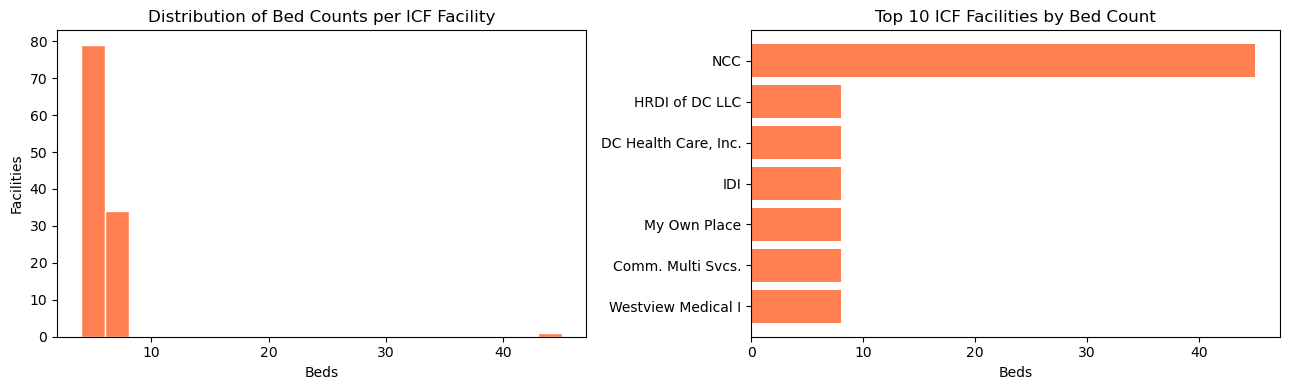

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].hist(raw_ICF["BEDS"], bins=20, color="coral", edgecolor="white")
axes[0].set_title("Distribution of Bed Counts per ICF Facility")
axes[0].set_xlabel("Beds")
axes[0].set_ylabel("Facilities")

top = raw_ICF.nlargest(10, "BEDS")[["NAME", "BEDS"]].reset_index(drop=True)
axes[1].barh(top["NAME"], top["BEDS"], color="coral")
axes[1].set_title("Top 10 ICF Facilities by Bed Count")
axes[1].set_xlabel("Beds")
axes[1].invert_yaxis()

plt.tight_layout()
plt.savefig("../outputs/figures/eda_02_beds_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

## 3. Prepare Analysis-Ready GeoDataFrame

In [10]:
# Build clean GeoDataFrame from raw shapefile
fac_gdf = raw_ICF[["geometry", "NAME", "BEDS"]].copy()
fac_gdf = fac_gdf.rename(columns={"NAME": "FAC_NAME", "BEDS": "CRTFD_BED_CNT"})
fac_gdf["CRTFD_BED_CNT"] = pd.to_numeric(fac_gdf["CRTFD_BED_CNT"], errors="coerce").fillna(0).astype(int)
fac_gdf = fac_gdf.to_crs(CRS)

print(f"Rows     : {len(fac_gdf)}")
print(f"Columns  : {list(fac_gdf.columns)}")
print(f"CRS      : {fac_gdf.crs}")
print(f"\nBed count stats:\n{fac_gdf['CRTFD_BED_CNT'].describe().to_string()}")

Rows     : 114
Columns  : ['geometry', 'FAC_NAME', 'CRTFD_BED_CNT']
CRS      : EPSG:26985

Bed count stats:
count    114.000000
mean       6.491228
std        3.870116
min        4.000000
25%        5.000000
50%        6.000000
75%        8.000000
max       45.000000


## 4. Spatial Distribution of ICF Facilities

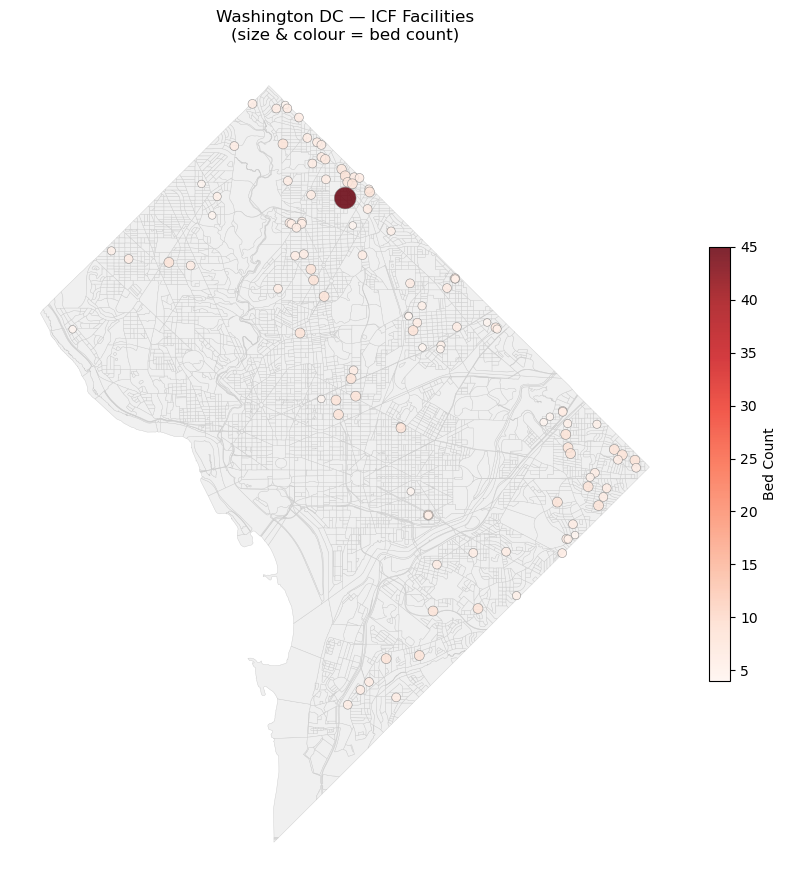

In [15]:
import numpy as np
import matplotlib.cm as cm
import matplotlib.colors as mcolors

# Load census blocks as backdrop
blocks = gpd.read_file(Blocks_DC).to_crs(CRS)

# Normalize marker sizes: 30 (smallest) → 250 (largest)
beds = fac_gdf["CRTFD_BED_CNT"].values.astype(float)
sizes = 30 + 220 * (beds - beds.min()) / (beds.max() - beds.min() + 1)

# Normalize color scale
norm = mcolors.Normalize(vmin=beds.min(), vmax=beds.max())
cmap = cm.Reds

fig, ax = plt.subplots(figsize=(8, 9))

blocks.plot(ax=ax, color="#f0f0f0", edgecolor="#cccccc", linewidth=0.3)

sc = ax.scatter(
    fac_gdf.geometry.x,
    fac_gdf.geometry.y,
    c=beds,
    cmap=cmap,
    norm=norm,
    s=sizes,
    edgecolors="grey",
    linewidths=0.4,
    zorder=3,
    alpha=0.85,
)

plt.colorbar(sc, ax=ax, label="Bed Count", fraction=0.03, pad=0.04)
ax.set_title("Washington DC — ICF Facilities\n(size & colour = bed count)", fontsize=12)
ax.set_axis_off()
plt.tight_layout()
plt.savefig("../outputs/figures/eda_02_facilities_map.png", dpi=150, bbox_inches="tight")
plt.show()

## 5. Summary

In [16]:
print(f"Total facilities      : {len(fac_gdf)}")
print(f"Total licensed beds   : {int(fac_gdf['CRTFD_BED_CNT'].sum())}")
print(f"Mean beds / facility  : {fac_gdf['CRTFD_BED_CNT'].mean():.1f}")
print(f"Smallest facility     : {int(fac_gdf['CRTFD_BED_CNT'].min())} beds")
print(f"Largest facility      : {int(fac_gdf['CRTFD_BED_CNT'].max())} beds")

Total facilities      : 114
Total licensed beds   : 740
Mean beds / facility  : 6.5
Smallest facility     : 4 beds
Largest facility      : 45 beds
